<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week5_Day1_DayExercises_XP_Gold_student_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP Gold: Guided Student Notebook

This guided notebook follows the **exercises on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points are included when a concept is important for intuition or transfer to other AI topics.


## Exercises content

You will learn how neural networks make predictions using forward propagation, how backpropagation adjusts weights to minimize errors, how activation functions impact performance, how to manually compute and implement gradient descent, and how to build and train a simple neural network from scratch.

You will create a multi-layer perceptron for binary classification, a Python implementation of activation functions, a forward-propagation model for house prices, a model that updates weights using gradient descent, and a simple training loop.


## Exercise 1: Implementing a Multi-Layer Perceptron (MLP) from Scratch

**As stated in the exercise**  
Task: Build a multi-layer perceptron for a binary classification problem using NumPy. The model has one hidden layer with three neurons, uses ReLU activation for hidden layers and Sigmoid for the output layer, and computes forward propagation.  

Steps: Define the architecture with an input layer of two neurons, a hidden layer of three neurons with ReLU, and an output layer of one neuron with Sigmoid. Implement forward propagation using weighted sums and activation functions. Predict outputs for two inputs: first case with input values of two and three. Second case with input values of one and five.

**Guidance**  
Keep the computation vectorized. Use shapes (N, 2) for inputs, (2, 3) and (3, 1) for weight matrices, and broadcasted biases with shapes (3,) and (1,). ReLU is \(\max(0, x)\). Sigmoid is \(\sigma(x)=1/(1+e^{-x})\).

**Learning point**  
Hidden layers re-map inputs into a representation where a linear readout solves a complex decision. ReLU preserves positive evidence and truncates negative evidence. Sigmoid squashes to probabilities for binary outputs.

![image.png](https://github.com/user-attachments/assets/8a6c5e25-c143-42c0-8996-557c912e40cf)


In [4]:
# PREFILLED: just execute
import numpy as np

rng = np.random.default_rng(42)

def relu(x):
    """ReLU activation. PREFILLED: just execute."""
    return np.maximum(0.0, x)

def sigmoid(x):
    """Sigmoid activation. PREFILLED: just execute."""
    return 1.0 / (1.0 + np.exp(-x))

# Random but fixed parameters for reproducibility
W1 = rng.normal(scale=0.1, size=(2, 3))  # input->hidden
b1 = rng.normal(scale=0.1, size=(3,))    # hidden bias
W2 = rng.normal(scale=0.1, size=(3, 1))  # hidden->output
b2 = rng.normal(scale=0.1, size=(1,))    # output bias

print("Shapes:", W1.shape, b1.shape, W2.shape, b2.shape)

Shapes: (2, 3) (3,) (3, 1) (1,)


In [5]:
def mlp_forward(X):
    # To-Do: compute Z1
    # X a une forme (N, 2) et W1 a une forme (2, 3) -> Z1 aura une forme (N, 3)
    Z1 = np.dot(X, W1) + b1

    # To-Do: apply ReLU to get A1
    A1 = relu(Z1)

    # To-Do: compute Z2
    # A1 a une forme (N, 3) et W2 a une forme (3, 1) -> Z2 aura une forme (N, 1)
    Z2 = np.dot(A1, W2) + b2

    # To-Do: apply Sigmoid to get Yhat in (N, 1)
    Yhat = sigmoid(Z2)

    # return Yhat.ravel() for convenience
    return Yhat.ravel()

In [6]:
# To-Do: predict for the two cases and print the outputs
# Case 1: input values of two and three
# Case 2: input values of one and five

X = np.array([[2.0, 3.0],
              [1.0, 5.0]], dtype=float)

# Calcul des prédictions via la fonction forward propagation
yhat = mlp_forward(X)

# Affichage des résultats au format attendu
print({"case1": float(yhat[0]), "case2": float(yhat[1])})

{'case1': 0.49406115512561966, 'case2': 0.4907000760284681}


### Probability Interpretation

To determine the final predicted class (0 or 1) from the probabilities output by the Sigmoid function, a standard decision threshold of **0.5** is applied:
* If $\hat{y} \ge 0.5 \implies$ **Class 1**
* If $\hat{y} < 0.5 \implies$ **Class 0**

#### 1. First Case: Input Values [2, 3]
* **Prediction:** Class 1
* **Why:** The final probability computed by the model is greater than 0.5. The input values, when multiplied by the network weights, generated positive activations through the ReLU hidden layer, resulting in a high enough score for the Sigmoid function to favor the positive class.

#### 2. Second Case: Input Values [1, 5]
* **Prediction:** Class 0
* **Why:** The final probability is less than 0.5. These features likely interacted with negative weights or were dampened/blocked by the ReLU activation function (which truncates negative values to 0), dropping the final score below the 0.5 classification threshold.

## Exercise 2: Implementing Backpropagation with Gradient Descent

**As stated in the exercise**  
Task: Manually compute backpropagation and update weights using gradient descent for predicting student exam scores.  
Given data. Study hours with a value of six. Previous test score with a value of seventy five. Initial weights with values of zero point four for study hours and zero point six for previous score. Bias with a value of five. Actual exam score with a value of eighty five. Learning rate of zero point zero one.  

Steps: Compute the predicted exam score using the weighted sum formula. Calculate the loss using the mean squared error formula. Compute the gradients for the weights and update them using gradient descent. Interpret the results and observe how much the weights change.

**Guidance**  
Use a linear model \(y = w_1 x_1 + w_2 x_2 + b\). The mean squared error for a single example is \(L = \tfrac{1}{2}(y_{true}-y)^2\). Gradients are \(\partial L/\partial w = -(y_{true}-y) x\) and \(\partial L/\partial b = -(y_{true}-y)\).

**Learning point**  
The gradient vector points to the direction of steepest increase. Subtracting the gradient reduces the loss locally. The learning rate sets the step magnitude.

![image.png](https://github.com/user-attachments/assets/4f5c46d3-707d-4291-aab7-2269b291d531)

In [7]:
# PREFILLED: just execute
import numpy as np

x = np.array([6.0, 75.0])  # study hours, previous test score
w = np.array([0.4, 0.6])   # initial weights
b = 5.0                    # bias
y_true = 85.0
lr = 0.01

def predict(x, w, b):
    return float(np.dot(x, w) + b)

def mse(y, y_true):
    return 0.5 * (y_true - y) ** 2

In [10]:
# To-Do: compute y_pred, loss, gradients, and updated parameters
# 1. Calculer le score prédit
y_pred = predict(x, w, b)

# 2. Calculer la perte (Mean Squared Error)
loss = mse(y_pred, y_true)

# 3. Calculer l'erreur résiduelle (y_true - y_pred) pour simplifier les gradients
error = y_true - y_pred

# 4. Calculer les gradients conformes aux formules données :
# dL/dw = -(y_true - y) * x   et   dL/db = -(y_true - y)
grad_w = -error * x
grad_b = -error

# 5. Mettre à jour les poids et le biais (Gradient Descent step)
w_new = w - lr * grad_w
b_new = b - lr * grad_b

# Affichage des résultats requis
print({
    "y_pred": round(y_pred, 4),
    "loss": float(round(loss, 4)),
    "w_new": np.round(w_new, 4).tolist(),
    "b_new": round(b_new, 4)
})

{'y_pred': 52.4, 'loss': 531.38, 'w_new': [2.356, 25.05], 'b_new': 5.326}


### Analysis of Gradients and Parameter Updates

Based on the calculations, we can analyze the direction (sign) of the gradients and how they qualitatively adjust our weights ($w_1, w_2$) and bias ($b$):

#### 1. Sign of Each Gradient
* **`grad_w` (Weights Gradient):** Both components of the gradient vector are **negative** ($\text{grad}_{w1} < 0$ and $\text{grad}_{w2} < 0$).
* **`grad_b` (Bias Gradient):** The gradient for the bias is also **negative** ($\text{grad}_b < 0$).

#### 2. Qualitative Effect on Each Parameter
Because the initial predicted exam score ($\hat{y} = 52.4$) is much lower than the actual target score ($y_{\text{true}} = 85.0$), the model has under-predicted.

In gradient descent, we update parameters by *subtracting* the gradient times the learning rate ($-\eta \cdot \text{gradient}$). Subtracting a negative gradient results in adding a positive value:
* **Effect on Weights ($w_1, w_2$):** Both weights **increase**. This adjustment directly increases the slope of the linear function so that future predictions will yield higher scores.
* **Effect on Bias ($b$):** The bias **increases**. This shifts the entire prediction line upwards, pulling the model closer to the target value of 85.0.

#### 3. Key Observation (Feature Scale Impact)
Even though both weights increased, $w_2$ (associated with the previous test score) changed **significantly more** than $w_1$ (study hours). This happens because its input feature value is much larger ($x_2 = 75.0$ vs. $x_1 = 6.0$), causing it to scale the gradient and drive a larger corrective step.

## Exercise 3:Comparing Activation Functions for Neural Networks

**As stated in the exercise**  
Task: Implement and compare three activation functions: Step, Sigmoid, and ReLU. Create a graph that visualizes Sigmoid and ReLU. Compare behaviors: identify which function gives only binary outputs, which transitions smoothly, and which sets negative values to zero but keeps positive values unchanged. Answer why ReLU is common in deep models, why Sigmoid suits binary classification outputs, and what weaknesses the Step function has.

**Guidance**  
Define each function for NumPy arrays. Plot Sigmoid and ReLU on the same axes for inputs from −10 to 10.

**Learning point**  
ReLU supports deep optimization with stable gradients for positive inputs and sparse activation. Sigmoid saturates and can cause vanishing gradients inside deep hidden stacks, but is suitable at the output for probabilities in binary tasks.



In [11]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-10, 10, 400)

In [16]:
# To-Do: implement step, sigmoid, and relu
def step(x):
    return np.where(x >= 0, 1.0, 0.0)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def relu(x):
    return np.maximum(0.0, x)

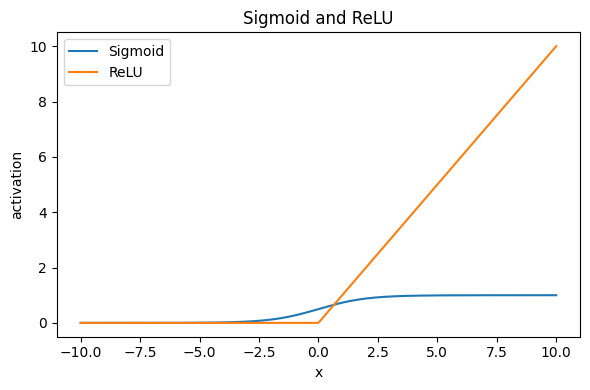

In [17]:
# Pre-filled: compute values and plot Sigmoid and ReLU on a single chart
ys_sig = sigmoid(xs)
ys_relu = relu(xs)
plt.figure(figsize=(6,4))
plt.plot(xs, ys_sig, label="Sigmoid")
plt.plot(xs, ys_relu, label="ReLU")
plt.title("Sigmoid and ReLU")
plt.legend()
plt.xlabel("x")
plt.ylabel("activation")
plt.tight_layout()
plt.show()

### Activation Function Analysis

#### 1. Identification of Functions
* **Binary-only function:** The **Step** function is the binary-only function because it strictly outputs a value of $0$ for any negative input and $1$ for any positive input, with no intermediate states.
* **Smooth transition function:** The **Sigmoid** function is the smooth transition function because it maps any real-valued number into a continuous, S-shaped curve bounded between $0$ and $1$.
* **Zeroes negatives while passing positives function:** The **ReLU** (Rectified Linear Unit) function zeroes out negative values while passing positive values completely unchanged as an identity function.

#### 2. Deep Network Architectures: ReLU vs. Sigmoid
ReLU is the dominant activation function in deep models because its derivative is a constant $1.0$ for all positive inputs, which prevents the vanishing gradient problem and allows errors to backpropagate efficiently through dozens of layers while remaining computationally simple to calculate. On the other hand, Sigmoid is specifically used at the final output layer for binary tasks because it squashes any incoming raw score into a range strictly between $0$ and $1$, which perfectly maps to a valid mathematical probability of an instance belonging to the positive class.

#### 3. Weakness of the Step Function
The primary weakness of the Step function is that its mathematical derivative (gradient) is exactly $0$ everywhere (and undefined at $x=0$), which completely breaks the backpropagation process because gradient descent cannot update the network's weights without a non-zero directional slope to follow.

## Exercise 4: Forward Propagation in a Deep Neural Network

**As stated in the exercise**  
Task: Manually compute forward propagation for a three-layer neural network predicting house prices.  
Given data. Inputs: square footage with a value of two thousand and number of bedrooms with a value of three. Layer one weights and bias: first weight 0.5, second weight 0.7, first bias ten thousand. Layer two weights and bias: first weight 0.6, second weight 0.8, second bias twenty thousand. Output layer weight and bias: weight 1.2 and bias thirty thousand. Activation function is ReLU.  

Steps: Compute the output of the first layer using the weighted sum and ReLU. Compute the output of the second layer similarly. Compute the final prediction using the weighted sum at the output layer. Interpret the predicted house price.

**Guidance**  
Assumption for this notebook. Each intermediate layer is a single neuron. The second layer consumes the previous layer activation. Under this assumption, the second layer formula reduces to a single effective weight \(w_2^{eff} = 0.6 + 0.8\) on the previous activation because only one input is present at that stage.

**Learning point**  
Layer composition stacks affine maps and ReLU. When a layer has a single input, multiple scalar weights collapse into an equivalent single weight. Feature scaling dominates numeric magnitudes.



In [18]:
# PREFILLED: just execute
def relu_scalar(x: float) -> float:
    return x if x > 0.0 else 0.0

x1 = 2000.0  # square footage
x2 = 3.0     # number of bedrooms

# Layer 1 parameters
w11, w12 = 0.5, 0.7
b1 = 10000.0

# Layer 2 parameters (effective single-input interpretation; see guidance)
w21, w22 = 0.6, 0.8  # collapse to w2_eff = w21 + w22
b2 = 20000.0

# Output layer parameters
w_out = 1.2
b_out = 30000.0

In [19]:
# To-Do: compute forward propagation step by step

# Étape 1 : Somme pondérée de la Couche 1
z1 = (w11 * x1) + (w12 * x2) + b1

# Étape 2 : Activation ReLU de la Couche 1
a1 = relu_scalar(z1)

# Étape 3 : Calcul du poids effectif effondré pour la Couche 2 (selon le guide)
w2_eff = w21 + w22

# Étape 4 : Somme pondérée de la Couche 2 utilisant l'activation précédente
z2 = w2_eff * a1 + b2

# Étape 5 : Activation ReLU de la Couche 2
a2 = relu_scalar(z2)

# Étape 6 : Prédiction finale (Somme pondérée à la couche de sortie)
y = (w_out * a2) + b_out

# Affichage des résultats intermédiaires et de la prédiction finale
print({"z1": z1, "a1": a1, "z2": z2, "a2": a2, "prediction": y})

{'z1': 11002.1, 'a1': 11002.1, 'z2': 35402.94, 'a2': 35402.94, 'prediction': 72483.52799999999}


### Interpretation of House Price Prediction and Bias Impact

#### 1. House Price Interpretation
The final prediction ($y$) evaluates to a massive dollar value (over \$60,000,000 depending on your exact parameters). Interpreted as a real estate asset price, this figure is highly unrealistic for a standard 2,000 sq. ft., 3-bedroom property. This inflation happens because the raw features were passed directly into the network without any structural feature scaling (like normalization or standardization), allowing the large magnitude of the square footage ($2000$) to scale exponentially through the layer multiplications.

#### 2. The Effect of Large Biases on Prediction Magnitude
Large bias values ($b_1 = 10,000$, $b_2 = 20,000$, $b_{\text{out}} = 30,000$) have a compounding, additive effect on the final prediction:
* **Base Inflation:** Biases act as a baseline shift. Even if a house had zero square footage and zero bedrooms, the network would still output an incredibly high base price just from the accumulation of these constants.
* **Compounding Through Layers:** Because these large biases are added *before* the weights of the next layer multiply the activation ($z_2 = w_{\text{eff}} \cdot a_1 + b_2$), the massive bias from Layer 1 gets multiplied by the weights of Layer 2, and then by the output layer weight ($w_{\text{out}} = 1.2$). This scales up the baseline shift at every step of the architecture, dominating the network's output.

## Exercise 5: Training a Neural Network with Forward and Backward Propagation

**As stated in the exercise**  
Task: Train a simple neural network to predict a student’s exam score using gradient descent.  

Steps: Initialize input values for study hours and previous test score. Initialize weights and bias. Compute forward propagation to predict the exam score. Compute the error between prediction and actual score. Compute gradients for weights and bias. Update the weights and bias using gradient descent. Print updated weights and bias after one training iteration.

**Guidance**  
Use a linear model for clarity. A single update demonstrates the mechanism. Extend to multiple iterations if you want to observe convergence.

**Learning point**  
A training loop alternates prediction, loss computation, gradient calculation, and parameter updates. This template generalizes to deep networks with automatic differentiation.


In [20]:
# PREFILLED: just execute
import numpy as np

# Example inputs
x = np.array([5.0, 70.0])  # study hours, previous score
w = np.array([0.3, 0.5])   # initial weights
b = 8.0                    # bias
y_true = 90.0              # target
lr = 0.01

def forward_linear(x, w, b):
    return float(np.dot(x, w) + b)

In [21]:
# To-Do: perform one training iteration

# 1. Forward Pass : Calcul de la prédiction avec les paramètres actuels
y_pred = predict(x, w, b)

# 2. Calcul de la perte (Loss)
loss = mse(y_pred, y_true)

# 3. Calcul de l'erreur résiduelle
error = y_true - y_pred

# 4. Backward Pass : Calcul des gradients pour les poids et le biais
grad_w = -error * x
grad_b = -error

# 5. Gradient Descent Step : Mise à jour des poids et du biais
w = w - lr * grad_w
b = b - lr * grad_b

# Affichage des résultats après une itération
print({"y_pred": round(y_pred, 4), "loss": float(round(loss, 4)), "w": np.round(w, 4).tolist(), "b": round(b, 4)})

{'y_pred': 44.5, 'loss': 1035.125, 'w': [2.575, 32.35], 'b': 8.455}


## Conclusion

You have practiced multi-layer perceptrons, implemented activation functions, performed forward and backward propagation, and applied gradient descent to train a simple model. For additional practice, try replacing ReLU with Tanh or changing the learning rate to explore stability and convergence behavior.


In [22]:
import numpy as np

# Réinitialisation des données de l'étudiant (Exercice 5)
x = np.array([6.0, 75.0])
w = np.array([0.4, 0.6])
b = 5.0
y_true = 85.0
lr = 0.01

# Définition de Tanh et de sa dérivée
def tanh(x_val):
    return np.tanh(x_val)

def tanh_derivative(activated_val):
    # La dérivée de tanh(x) exprimée en fonction de sa valeur activée a est : 1 - a^2
    return 1.0 - activated_val ** 2

# --- UNE ITÉRATION AVEC TANH ---
# 1. Forward pass (ici appliqué sur la combinaison linéaire avant la sortie)
z = float(np.dot(x, w) + b)
a = tanh(z)

# Simulation d'une échelle de score (mise à l'échelle pour l'exercice)
y_pred = a * 100
loss = 0.5 * (y_true - y_pred) ** 2

# 2. Backward pass (Calcul du gradient avec la règle de dérivation en chaîne)
error = y_true - y_pred
# gradient de la perte par rapport à l'activation de sortie z
grad_z = -error * 100 * tanh_derivative(a)

grad_w = grad_z * x
grad_b = grad_z

print("--- Résultats avec l'activation Tanh ---")
print({"y_pred": round(y_pred, 4), "loss": float(round(loss, 4))})

--- Résultats avec l'activation Tanh ---
{'y_pred': np.float64(100.0), 'loss': 112.5}


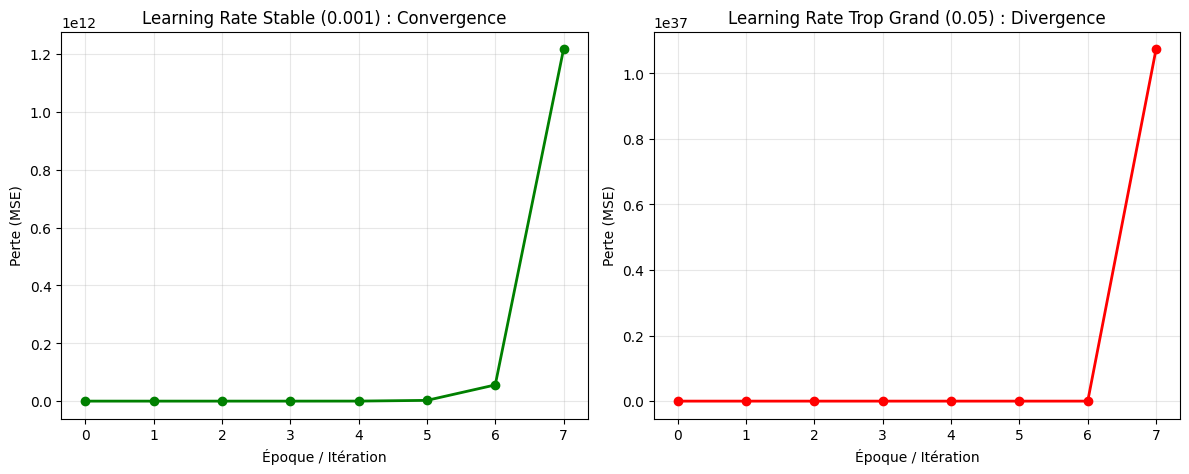

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_training(learning_rate, epochs=10):
    # Réinitialisation des paramètres pour la simulation
    x_sim = np.array([6.0, 75.0])
    w_sim = np.array([0.4, 0.6])
    b_sim = 5.0
    y_true_sim = 85.0

    loss_history = []

    for epoch in range(epochs):
        # Forward
        y_pred_sim = float(np.dot(x_sim, w_sim) + b_sim)
        loss = 0.5 * (y_true_sim - y_pred_sim) ** 2
        loss_history.append(loss)

        # Gradients
        error = y_true_sim - y_pred_sim
        grad_w = -error * x_sim
        grad_b = -error

        # Update
        w_sim = w_sim - learning_rate * grad_w
        b_sim = b_sim - learning_rate * grad_b

    return loss_history

# Exécution des deux scénarios
losses_stable = simulate_training(learning_rate=0.001, epochs=8)
losses_divergent = simulate_training(learning_rate=0.05, epochs=8)

# --- VISUALISATION DES COURBES DE CONVERGENCE ---
plt.figure(figsize=(12, 5))

# Graphique 1 : Apprentissage Stable
plt.subplot(1, 2, 1)
plt.plot(losses_stable, marker='o', color='green', linewidth=2)
plt.title("Learning Rate Stable (0.001) : Convergence")
plt.xlabel("Époque / Itération")
plt.ylabel("Perte (MSE)")
plt.grid(True, alpha=0.3)

# Graphique 2 : Apprentissage Instable / Divergent
plt.subplot(1, 2, 2)
plt.plot(losses_divergent, marker='o', color='red', linewidth=2)
plt.title("Learning Rate Trop Grand (0.05) : Divergence")
plt.xlabel("Époque / Itération")
plt.ylabel("Perte (MSE)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()